In [41]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import ipywidgets as widgets
from IPython.display import  clear_output
from IPython.display import display as ipython_display
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# Adjust this path to your project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

# Import your solver and environment classes
from numerical.solvers.dg_wave_solver_mixed_clean import DGWaveSolverMixed
from numerical.environments.dg_amr_env_mixed import DGAMREnv, RewardCalculator

# Define action mapping for clarity
ACTION_NAMES = {
    -1: "Coarsen",
    0: "No Change",
    1: "Refine"
}

In [ ]:
class InteractiveAMRTester:
    """Interactive environment for testing AMR actions and rewards"""
    
    def __init__(self, 
                 nop=4, 
                 initial_elements=np.array([-1, -0.5, 0, 0.5, 1]), 
                 max_level=4,
                 element_budget=25,
                 gamma_c=25.0,
                 machine_eps=1e-16,
                 initial_refinement_level=1,
                 accuracy_scaling=1.0):
        """Initialize the testing environment"""
        self.nop = nop
        self.initial_elements = initial_elements
        self.max_level = max_level
        self.element_budget = element_budget
        self.gamma_c = gamma_c
        self.machine_eps = machine_eps
        self.accuracy_scaling = accuracy_scaling
        
        # Create solver and environment
        self.create_environment(initial_refinement_level)
        
        # Initialize action history tracking
        self.action_history = []
        self.reward_history = []
        self.element_history = []
        self.delta_u_history = []
        self.resource_history = []
        
        # Setup custom reward calculator for inspection
        self.reward_calc = RewardCalculator(gamma_c=gamma_c)
        self.reward_calc.machine_eps = machine_eps
        
        # Create interactive widgets
        self.setup_widgets()


    def debug_data_structures(self):
        """Print debug information about key data structures"""
        print("\nDebugging Data Structures:")
        
        print(f"xelem: shape={np.shape(self.env.solver.xelem)}")
        print(f"xelem first few elements: {self.env.solver.xelem[:5]}")
        
        print(f"active elements: count={len(self.env.solver.active)}")
        print(f"active first few elements: {self.env.solver.active[:5]}")
        
        print(f"label_mat: shape={np.shape(self.env.solver.label_mat)}")
        if len(self.env.solver.active) > 0:
            first_elem = self.env.solver.active[0]
            print(f"label_mat for first element: {self.env.solver.label_mat[first_elem-1]}")
        
        print(f"info_mat: shape={np.shape(self.env.solver.info_mat)}")
        if len(self.env.solver.active) > 0:
            first_elem = self.env.solver.active[0]
            print(f"info_mat for first element: {self.env.solver.info_mat[first_elem-1]}")

    def create_environment(self, initial_refinement_level):
            """Create the solver and environment objects"""
            # Create solver
            self.solver = DGWaveSolverMixed(
                nop=self.nop,
                xelem=self.initial_elements,
                max_elements=self.element_budget * 2,
                max_level=self.max_level,
                courant_max=0.1,
                icase=1,
                verbose=True,
                balance=False  # Disable balance for simplicity
            )
            
            # Create environment
            self.env = DGAMREnv(
                solver=self.solver,
                element_budget=self.element_budget,
                gamma_c=self.gamma_c,
                max_episode_steps=100,
                verbose=True,
                rl_iterations_per_timestep=100,
                max_rl_iterations=5,
                debug_training_cycle=True  # Enable detailed debugging
            )
            
            # Reset environment with specified refinement level
            self.obs, self.info = self.env.reset(options={
                'refinement_mode': 'fixed',
                'refinement_level': initial_refinement_level
            })
            
            # Store initial state
            self.previous_solution = self.env.solver.q.copy()
            self.previous_resource = len(self.env.solver.active) / self.element_budget
            self.selected_element = None
            self.selected_action = None
            self.debug_data_structures
        
    def setup_widgets(self):
        """Create the interactive widgets for the notebook"""
        # Element selection slider
        self.element_slider = widgets.IntSlider(
            min=1,
            max=len(self.env.solver.active),
            step=1,
            description='Element:',
            continuous_update=False
        )
        
        # Action selection radio buttons
        self.action_radio = widgets.RadioButtons(
            options=[('Coarsen', 0), ('No Change', 1), ('Refine', 2)],
            description='Action:',
            disabled=False
        )
        
        # Apply action button
        self.apply_button = widgets.Button(
            description='Apply Action',
            button_style='success',
            tooltip='Apply the selected action to the element'
        )
        self.apply_button.on_click(self.on_apply_action)
        
        # Reset environment button
        self.reset_button = widgets.Button(
            description='Reset Environment',
            button_style='warning',
            tooltip='Reset the environment to initial state'
        )
        self.reset_button.on_click(self.on_reset)
        
        # Element budget and gamma sliders
        self.budget_slider = widgets.IntSlider(
            min=5,
            max=50,
            step=5,
            value=self.element_budget,
            description='Budget:',
            continuous_update=False
        )
        
        self.gamma_slider = widgets.FloatSlider(
            min=1.0,
            max=100.0,
            step=1.0,
            value=self.gamma_c,
            description='Gamma_c:',
            continuous_update=False
        )
        
        # Machine epsilon slider (log scale)
        self.epsilon_slider = widgets.FloatLogSlider(
            base=10,
            min=-16,  # 10^-16
            max=-4,   # 10^-4
            step=1,
            value=self.machine_eps,
            description='Machine ε:',
            continuous_update=False
        )
        
        # Accuracy scaling slider
        self.scaling_slider = widgets.FloatSlider(
            min=0.01,
            max=2.0,
            step=0.01,
            value=self.accuracy_scaling,
            description='Acc. Scale:',
            continuous_update=False
        )
        
        # Apply settings button
        self.settings_button = widgets.Button(
            description='Apply Settings',
            button_style='info',
            tooltip='Apply new environment settings'
        )
        self.settings_button.on_click(self.on_apply_settings)
        
        # Take timestep button
        self.timestep_button = widgets.Button(
            description='Take Timestep',
            button_style='primary',
            tooltip='Advance the physical simulation one timestep'
        )
        self.timestep_button.on_click(self.on_take_timestep)
        
        # Arrange widgets
        self.element_action_box = widgets.VBox([
            self.element_slider,
            self.action_radio,
            self.apply_button
        ])
        
        self.settings_box = widgets.VBox([
            self.budget_slider,
            self.gamma_slider,
            self.epsilon_slider,
            self.scaling_slider,
            self.settings_button
        ])
        
        self.control_box = widgets.HBox([
            self.element_action_box,
                widgets.VBox([self.reset_button, self.timestep_button]),
                self.settings_box
            ])
        

    def on_apply_action(self, b):
        """Callback for when the apply action button is clicked"""
        self.selected_element = self.element_slider.value
        self.selected_action = self.action_radio.value
        
        # Get pre-action state
        pre_elements = len(self.env.solver.active)
        pre_resource = pre_elements / self.element_budget
        
        # Convert element index to active element ID
        element_id = self.env.solver.active[self.selected_element - 1]
        
        # Get the mapped action (-1, 0, 1)
        mapped_action = self.env.action_mapping[self.selected_action]
        
        # Store the previous solution and resource for delta calculation
        self.previous_solution = self.env.solver.q.copy()
        self.previous_resources = pre_resource
        
        # Display action information
        print(f"\nApplying {ACTION_NAMES[mapped_action]} to element {self.selected_element} (ID: {element_id})")
        
        # Create action mask for tracking
        action_mask = np.ones(len(self.env.solver.active), dtype=int)  # Default: no change
        action_mask[self.selected_element - 1] = self.selected_action
        
        # Save current element index
        original_element_index = self.env.current_element_index
        
        # Set environment's current element index to our selected element
        self.env.current_element_index = self.selected_element - 1
        
        # Apply the action using the standard step method
        obs, reward, terminated, truncated, info = self.env.step(self.selected_action)
        
        # Restore original element index
        self.env.current_element_index = original_element_index
        
        # Get post-action state
        post_elements = len(self.env.solver.active)
        post_resource = post_elements / self.element_budget
        delta_elements = post_elements - pre_elements
        
        # Calculate change in solution
        if 'delta_u' in info:
            delta_u = info['delta_u']
        else:
            delta_u = 0.0
        
        # Calculate barrier function values (B(p) = √p/(1-p))
        def calculate_barrier(p):
            if p >= 1.0:
                return float('inf')  
            elif p <= 0.0:
                return 0.0
            else:
                return np.sqrt(p) / (1 - p)
                
        old_barrier = calculate_barrier(pre_resource)
        new_barrier = calculate_barrier(post_resource)
        barrier_delta = new_barrier - old_barrier
        
        # Update histories - ADD ELEMENT HISTORY
        self.action_history.append({'action': ACTION_NAMES[mapped_action], 'element': self.selected_element})
        self.reward_history.append({
            'total': reward, 
            'accuracy': info.get('accuracy_term', 0.0), 
            'penalty': info.get('resource_penalty', 0.0)
        })
        self.resource_history.append({
            'pre': pre_resource,
            'post': post_resource,
            'delta': post_resource - pre_resource,
            'old_barrier': old_barrier,
            'new_barrier': new_barrier,
            'barrier_delta': barrier_delta
        })
        self.element_history.append({
            'pre': pre_elements,
            'post': post_elements,
            'delta': delta_elements
        })
        self.delta_u_history.append(delta_u)
        
        # Print detailed results
        print(f"Action result:")
        print(f"  Reward: {reward:.4f}")
        print(f"  Δu (solution change): {delta_u:.6e}")
        print(f"  Elements: {pre_elements} → {post_elements} (Δ{delta_elements:+d})")
        print(f"  Resource usage: {pre_resource*100:.1f}% → {post_resource*100:.1f}%")
        print(f"  Barrier function: {old_barrier:.4f} → {new_barrier:.4f} (Δ{barrier_delta:+.4f})")
        
        # Update visualization
        self.render()

        current_element_count = len(self.env.solver.active)
        self.element_slider.max = current_element_count
        
        # If selected element is out of range, reset to center
        if self.selected_element > current_element_count:
            self.element_slider.value = current_element_count // 2
        
        # Update the slider's description to show the new range
        self.element_slider.description = f'Element (1-{current_element_count}):'
        
        # If max refinement level reached, notify user
        element_level = info.get('element_level', -1)
        if mapped_action == 1 and element_level == self.env.solver.max_level:
            print(f"Note: Element {element_id} already at maximum refinement level ({self.env.solver.max_level})")
        elif mapped_action == -1 and element_level == 0:
            print(f"Note: Element {element_id} already at base level (0)")
    # def on_apply_action(self, b):
    #     """Callback for when the apply action button is clicked"""
    #     self.selected_element = self.element_slider.value
    #     self.selected_action = self.action_radio.value
        
    #     # Get pre-action state
    #     pre_elements = len(self.env.solver.active)
    #     pre_resource = pre_elements / self.element_budget
        
    #     # Convert element index to active element ID
    #     element_id = self.env.solver.active[self.selected_element - 1]
        
    #     # Get the mapped action (-1, 0, 1)
    #     mapped_action = self.env.action_mapping[self.selected_action]
        
    #     # Store the previous solution and resource for delta calculation
    #     self.previous_solution = self.env.solver.q.copy()
    #     self.previous_resources = pre_resource
        
    #     # Apply action through the environment
    #     print(f"\nApplying {ACTION_NAMES[mapped_action]} to element {self.selected_element} (ID: {element_id})")
        
    #     # Create action mask with the selected element
    #     action_mask = np.zeros(len(self.env.solver.active), dtype=int)
    #     action_mask[self.selected_element - 1] = self.selected_action
        
    #     # Take step with this action mask
    #     obs, reward, terminated, truncated, info = self.env.step_with_mask(action_mask)
        
    #     # Get post-action state
    #     post_elements = len(self.env.solver.active)
    #     post_resource = post_elements / self.element_budget
    #     delta_elements = post_elements - pre_elements
        
    #     # Extract delta_u and action info
    #     delta_u = info.get('delta_u', 0.0)
    #     actual_action = info.get('actual_action', mapped_action)
        
    #     # Manually calculate reward components for verification
    #     old_barrier = self.reward_calc.calculate_barrier(pre_resource)
    #     new_barrier = self.reward_calc.calculate_barrier(post_resource)
    #     resource_penalty = new_barrier - old_barrier
        
    #     # Calculate expected accuracy term with scaling
    #     if delta_u > 0:
    #         accuracy_term = np.log(abs(delta_u) + self.reward_calc.machine_eps) - np.log(self.reward_calc.machine_eps)
    #         accuracy_term *= self.accuracy_scaling
    #     else:
    #         accuracy_term = 0.0
            
    #     # Apply sign based on action
    #     if actual_action == 1:  # refine
    #         expected_accuracy = +accuracy_term
    #     elif actual_action == -1:  # coarsen
    #         expected_accuracy = -accuracy_term
    #     else:  # do nothing
    #         expected_accuracy = 0.0
            
    #     # Calculate expected reward
    #     expected_reward = expected_accuracy - self.gamma_c * resource_penalty
        
    #     # Record in history
    #     self.action_history.append({
    #         'element': self.selected_element,
    #         'action': ACTION_NAMES[mapped_action],
    #         'actual_action': ACTION_NAMES[actual_action] if actual_action in ACTION_NAMES else "Invalid"
    #     })
        
    #     self.reward_history.append({
    #         'total': reward,
    #         'expected': expected_reward,
    #         'accuracy': expected_accuracy,
    #         'penalty': resource_penalty * self.gamma_c
    #     })
        
    #     self.element_history.append({
    #         'pre': pre_elements,
    #         'post': post_elements,
    #         'delta': delta_elements
    #     })
        
    #     self.delta_u_history.append(delta_u)
    #     self.resource_history.append({
    #         'pre': pre_resource,
    #         'post': post_resource,
    #         'old_barrier': old_barrier,
    #         'new_barrier': new_barrier
    #     })
        
    #     # Update slider max value after mesh changes
    #     self.element_slider.max = len(self.env.solver.active)
        
    #     # If selected element is now out of bounds, reset to last element
    #     if self.selected_element > len(self.env.solver.active):
    #         self.element_slider.value = len(self.env.solver.active)
        
    #     # Display results
    #     self.render()
        
    #     # Print detailed results
    #     self.print_action_results(
    #         action=ACTION_NAMES[mapped_action],
    #         actual_action=ACTION_NAMES[actual_action] if actual_action in ACTION_NAMES else "Invalid",
    #         delta_u=delta_u,
    #         accuracy_term=accuracy_term,
    #         expected_accuracy=expected_accuracy,
    #         pre_resource=pre_resource,
    #         post_resource=post_resource,
    #         old_barrier=old_barrier,
    #         new_barrier=new_barrier,
    #         resource_penalty=resource_penalty,
    #         expected_reward=expected_reward,
    #         actual_reward=reward,
    #         pre_elements=pre_elements,
    #         post_elements=post_elements
    #     )
        
    def on_reset(self, b):
        """Reset the environment"""
        initial_refinement = int(np.log2(len(self.env.solver.active) / (len(self.initial_elements) - 1)))
        initial_refinement = max(1, min(initial_refinement, self.max_level))
        
        print(f"Resetting environment with refinement level {initial_refinement}...")
        self.obs, self.info = self.env.reset(options={
            'refinement_mode': 'fixed',
            'refinement_level': initial_refinement
        })
        
        # Reset history
        self.action_history = []
        self.reward_history = []
        self.element_history = []
        self.delta_u_history = []
        self.resource_history = []
        
        # Store initial state
        self.previous_solution = self.env.solver.q.copy()
        self.previous_resource = len(self.env.solver.active) / self.element_budget
        self.selected_element = None
        self.selected_action = None
        
        # Update slider max value
        self.element_slider.max = len(self.env.solver.active)
        self.element_slider.value = 1
        
        # Render the reset state
        self.render()
        print("Environment reset complete.")

    def on_apply_settings(self, b):
        """Apply new environment settings"""
        # Extract settings from widgets
        new_budget = self.budget_slider.value
        new_gamma = self.gamma_slider.value
        new_epsilon = self.epsilon_slider.value
        new_scaling = self.scaling_slider.value
        
        print(f"Applying new settings: Budget={new_budget}, Gamma={new_gamma}, Epsilon={new_epsilon:.1e}, Scaling={new_scaling}")
        
        # Store current values
        self.element_budget = new_budget
        self.gamma_c = new_gamma
        self.machine_eps = new_epsilon
        self.accuracy_scaling = new_scaling
        
        # Create new environment with these settings
        # Get current refinement level
        current_active = len(self.env.solver.active)
        current_refinement = int(np.log2(current_active / (len(self.initial_elements) - 1)))
        current_refinement = max(1, min(current_refinement, self.max_level))
        
        # Recreate environment with new settings
        self.create_environment(current_refinement)
        
        # Update reward calculator
        self.reward_calc = RewardCalculator(gamma_c=new_gamma)
        self.reward_calc.machine_eps = new_epsilon
        
        # Reset history since this is essentially a new environment
        self.action_history = []
        self.reward_history = []
        self.element_history = []
        self.delta_u_history = []
        self.resource_history = []
        
        # Update slider max value
        self.element_slider.max = len(self.env.solver.active)
        self.element_slider.value = 1
        
        # Render with new settings
        self.render()
        print("New settings applied successfully.")
        
    def on_take_timestep(self, b):
        """Advance the physical simulation by one timestep"""
        print("\nAdvancing physical simulation by one timestep...")
        
        # Store pre-timestep solution and state
        pre_solution = self.env.solver.q.copy()
        pre_elements = len(self.env.solver.active)
        pre_resource = pre_elements / self.element_budget
        
        # Take timestep (this is a custom method you'll need to add to your environment)
        # Alternatively, you can directly call the underlying solver's timestep method
        timestep_info = self.env.take_physical_timestep()
        
        # Calculate solution change
        post_solution = self.env.solver.q.copy()
        solution_change = np.linalg.norm(post_solution - pre_solution)
        
        # Update state tracking
        self.action_history.append({
            'element': None,
            'action': "Timestep",
            'actual_action': "Timestep"
        })
        
        self.reward_history.append({
            'total': None,
            'expected': None,
            'accuracy': None,
            'penalty': None
        })
        
        self.element_history.append({
            'pre': pre_elements,
            'post': pre_elements,  # No change in elements from timestep
            'delta': 0
        })
        
        self.delta_u_history.append(solution_change)
        self.resource_history.append({
            'pre': pre_resource,
            'post': pre_resource,
            'old_barrier': None,
            'new_barrier': None
        })
        
        # Render updated state
        self.render()
        
        print(f"Timestep complete. Solution change: {solution_change:.6e}")

    def print_action_results(self, action, actual_action, delta_u, accuracy_term,
                                expected_accuracy, pre_resource, post_resource,
                                old_barrier, new_barrier, resource_penalty,
                                expected_reward, actual_reward, pre_elements, post_elements):
            """Print detailed results of the action"""
            print("\n=== Action Results ===")
            print(f"Action: {action} (Actual: {actual_action})")
            print(f"Elements: {pre_elements} -> {post_elements} (Δ{post_elements-pre_elements})")
            print(f"Resource: {pre_resource:.4f} -> {post_resource:.4f}")
            print("\n--- Solution Impact ---")
            print(f"Delta_u: {delta_u:.6e}")
            print(f"log(Delta_u): {np.log(abs(delta_u) + self.machine_eps):.4f}")
            print(f"Accuracy term (unscaled): {accuracy_term/self.accuracy_scaling:.4f}")
            print(f"Accuracy term (scaled): {accuracy_term:.4f}")
            print(f"Expected accuracy contribution: {expected_accuracy:.4f}")
            print("\n--- Resource Impact ---")
            print(f"Old barrier: {old_barrier:.4f}")
            print(f"New barrier: {new_barrier:.4f}")
            print(f"Resource penalty: {resource_penalty:.4f}")
            print(f"Scaled penalty (gamma_c={self.gamma_c}): {self.gamma_c * resource_penalty:.4f}")
            print("\n--- Final Reward ---")
            print(f"Expected reward: {expected_reward:.4f}")
            print(f"Actual reward: {actual_reward:.4f}")
            print("=====================\n")

    def render(self):
            """Render the current state with visualizations"""
            clear_output(wait=True)
            
            # Create figure with subplots
            fig = plt.figure(figsize=(18, 12))
            gs = gridspec.GridSpec(3, 3, figure=fig)
            
            # Subplot 1: Current mesh visualization
            ax1 = fig.add_subplot(gs[0, :])
            self.plot_mesh_state(ax1)
            
            # Subplot 2: Solution visualization
            ax2 = fig.add_subplot(gs[1, :])
            self.plot_solution(ax2)
            
            # Subplot 3: Action history
            ax3 = fig.add_subplot(gs[2, 0])
            self.plot_action_history(ax3)
            
            # Subplot 4: Reward history
            ax4 = fig.add_subplot(gs[2, 1])
            self.plot_reward_history(ax4)
            
            # Subplot 5: Resource usage
            ax5 = fig.add_subplot(gs[2, 2])
            self.plot_resource_history(ax5)
            
            plt.tight_layout()
            plt.show()
            
            # Display the control widgets
            ipython_display(self.control_box) 
            # display(self.control_box)
        
    def plot_mesh_state(self, ax):
        """Plot the current mesh state with element levels"""
        # Get element boundaries and levels
        active_elements = self.env.solver.active
        xelem = self.env.solver.xelem  # Keep this for domain boundaries

        
        levels = []
        element_centers = []
        element_widths = []
        
        for i, elem_id in enumerate(active_elements):
            # Element levels (assuming 1-indexed elements)
            level = self.env.solver.label_mat[elem_id-1][4]
            levels.append(level)
            
            # Instead of using label_mat indices with xelem, use coordinate info directly
            # Get left and right coordinates from info_mat (last two columns)
            x_left = self.env.solver.info_mat[elem_id-1][-2]  # Second-to-last column
            x_right = self.env.solver.info_mat[elem_id-1][-1]  # Last column
            
            width = x_right - x_left
            center = (x_left + x_right) / 2
            
            element_centers.append(center)
            element_widths.append(width)
    
    
        
        # Plot the elements as boxes with levels as heights
        for i, (center, width, level) in enumerate(zip(element_centers, element_widths, levels)):
            rect = patches.Rectangle(
                (center - width/2, 0), 
                width, level,
                linewidth=2,
                edgecolor='blue',
                facecolor='lightblue' if i+1 != self.selected_element else 'orange',
                alpha=0.7
            )
            ax.add_patch(rect)
            
            # Add element indices
            ax.text(center, level + 0.1, str(i+1), 
                    ha='center', va='bottom', fontsize=10)
        
        # Plot domain boundaries
        ax.axvline(xelem[0], color='black', linestyle='-')
        ax.axvline(xelem[-1], color='black', linestyle='-')
        
        ax.set_xlim(xelem[0] - 0.1, xelem[-1] + 0.1)
        ax.set_ylim(0, self.max_level + 1)
        ax.set_ylabel('Refinement Level')
        ax.set_xlabel('x coordinate')
        ax.set_title(f'Current Mesh State - {len(active_elements)}/{self.element_budget} Elements')
        ax.grid(True)
        
    def plot_solution(self, ax):
        """Plot the current solution on the mesh"""
        # Extract solution data
        x = self.env.solver.coord
        q = self.env.solver.q
        
        # Plot the solution
        ax.plot(x, q, 'b-', linewidth=2)
        
        # Highlight boundaries between elements
        for elem_id in self.env.solver.active:
            # Get actual coordinates from info_mat
            x_left = self.env.solver.info_mat[elem_id-1][-2]
            x_right = self.env.solver.info_mat[elem_id-1][-1]
            
            ax.axvline(x_left, color='gray', linestyle='--', alpha=0.5)
            ax.axvline(x_right, color='gray', linestyle='--', alpha=0.5)
        
        # If an element is selected, highlight it
        if self.selected_element is not None:
            elem_id = self.env.solver.active[self.selected_element-1]
            x_left = self.env.solver.info_mat[elem_id-1][-2]
            x_right = self.env.solver.info_mat[elem_id-1][-1]
            
            # Add shaded region for selected element
            ax.axvspan(x_left, x_right, alpha=0.3, color='orange')
            
            # Add label for selected element
            ax.text((x_left + x_right)/2, ax.get_ylim()[1]*0.9, 
                    f'Element {self.selected_element}', 
                    ha='center', va='center', 
                    bbox=dict(facecolor='white', alpha=0.7))
        
        ax.set_xlim(self.env.solver.xelem[0], self.env.solver.xelem[-1])
        ax.set_xlabel('x coordinate')
        ax.set_ylabel('Solution (q)')
        ax.set_title('Current Solution')
        ax.grid(True)
        
    def plot_action_history(self, ax):
        """Plot the history of actions taken"""
        if not self.action_history:
            ax.text(0.5, 0.5, "No actions yet", ha='center', va='center')
            ax.set_title('Action History')
            ax.set_xticks([])
            ax.set_yticks([])
            return
        
        # Prepare data
        step_nums = range(1, len(self.action_history) + 1)
        action_types = [h['action'] for h in self.action_history]
        
        # Create color map for actions
        action_colors = {
            'Refine': 'green',
            'Coarsen': 'red',
            'No Change': 'blue',
            'Timestep': 'purple'
        }
        
        colors = [action_colors.get(a, 'gray') for a in action_types]
        
        # Plot action history as bars
        bars = ax.bar(step_nums, [1] * len(step_nums), color=colors)
        
        # Add action labels
        for i, (s, a) in enumerate(zip(step_nums, action_types)):
            ax.text(s, 0.5, a, ha='center', va='center', 
                    rotation=90 if len(a) > 5 else 0,
                    fontsize=8, color='white', fontweight='bold')
            
            # Add element number if available
            if self.action_history[i]['element'] is not None:
                ax.text(s, 1.1, f"#{self.action_history[i]['element']}", 
                        ha='center', va='bottom', fontsize=8)
        
        ax.set_ylim(0, 1.5)
        ax.set_xlim(0.5, len(step_nums) + 0.5)
        ax.set_xticks(step_nums)
        ax.set_xlabel('Step')
        ax.set_title('Action History')
        ax.set_yticks([])

    def plot_reward_history(self, ax):
        """Plot the history of rewards"""
        if not self.reward_history:
            ax.text(0.5, 0.5, "No rewards yet", ha='center', va='center')
            ax.set_title('Reward History')
            ax.set_xticks([])
            ax.set_yticks([])
            return
        
        # Prepare data
        step_nums = range(1, len(self.reward_history) + 1)
        
        # Filter out None values (from timesteps)
        valid_indices = [i for i, r in enumerate(self.reward_history) if r['total'] is not None]
        valid_steps = [step_nums[i] for i in valid_indices]
        
        if not valid_indices:
            ax.text(0.5, 0.5, "No rewards to display", ha='center', va='center')
            ax.set_title('Reward History')
            ax.set_xticks(step_nums)
            ax.set_xlabel('Step')
            return
        
        total_rewards = [self.reward_history[i]['total'] for i in valid_indices]
        accuracy_terms = [self.reward_history[i]['accuracy'] for i in valid_indices]
        penalty_terms = [-self.reward_history[i]['penalty'] for i in valid_indices]
        
        # Plot stacked bars for reward components
        ax.bar(valid_steps, accuracy_terms, color='green', label='Accuracy')
        ax.bar(valid_steps, penalty_terms, bottom=accuracy_terms, color='red', label='Resource Penalty')
        
        # Plot total reward as a line
        ax.plot(valid_steps, total_rewards, 'ko-', label='Total Reward')
        
        # Add y=0 line
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        
        ax.set_xlabel('Step')
        ax.set_ylabel('Reward Value')
        ax.set_title('Reward Components')
        ax.legend(loc='upper left', fontsize='small')
        ax.set_xticks(step_nums)
        
        # Add delta_u values as text
        for i, step in enumerate(valid_steps):
            delta_u = self.delta_u_history[step-1]
            if delta_u > 0:
                ax.text(step, total_rewards[i], 
                        f"Δu={delta_u:.2e}", 
                        ha='center', va='bottom', fontsize=8)

    def plot_resource_history(self, ax):
        """Plot the history of resource usage"""
        if not self.resource_history:
            ax.text(0.5, 0.5, "No resource data yet", ha='center', va='center')
            ax.set_title('Resource Usage')
            ax.set_xticks([])
            ax.set_yticks([])
            return
        
        # Prepare data
        step_nums = range(1, len(self.resource_history) + 1)
        post_resources = [r['post'] for r in self.resource_history]
        
        # Plot resource usage
        ax.plot(step_nums, post_resources, 'bo-', label='Resource Usage')
        
        # Add budget line
        ax.axhline(y=1.0, color='red', linestyle='--', label='Budget Limit')
        
        # Add barrier function values if available
        valid_indices = [i for i, r in enumerate(self.resource_history) if r['new_barrier'] is not None]
        if valid_indices:
            valid_steps = [step_nums[i] for i in valid_indices]
            barrier_values = [self.resource_history[i]['new_barrier'] / 10 for i in valid_indices]  # Scale down for visibility
            
            ax.plot(valid_steps, barrier_values, 'g.-', label='Barrier/10')
        
        ax.set_xlabel('Step')
        ax.set_ylabel('Resource Usage (p)')
        ax.set_title('Resource Usage History')
        ax.legend(loc='upper left', fontsize='small')
        ax.set_xticks(step_nums)
        ax.set_ylim(0, max(1.1, max(post_resources) * 1.1))
        
        # Add element counts as text
        for i, step in enumerate(step_nums):
            elements = self.element_history[i]['post']
            ax.text(step, post_resources[i], 
                    f"{elements}", 
                    ha='center', va='bottom', fontsize=8)

    def show_tester(self):
        """Initialize and display the interactive tester"""
        self.render()
        print("Interactive AMR Tester initialized.")
        print(f"Initial state: {len(self.env.solver.active)}/{self.element_budget} elements")
        print("Use the widgets below to select elements and apply actions.")

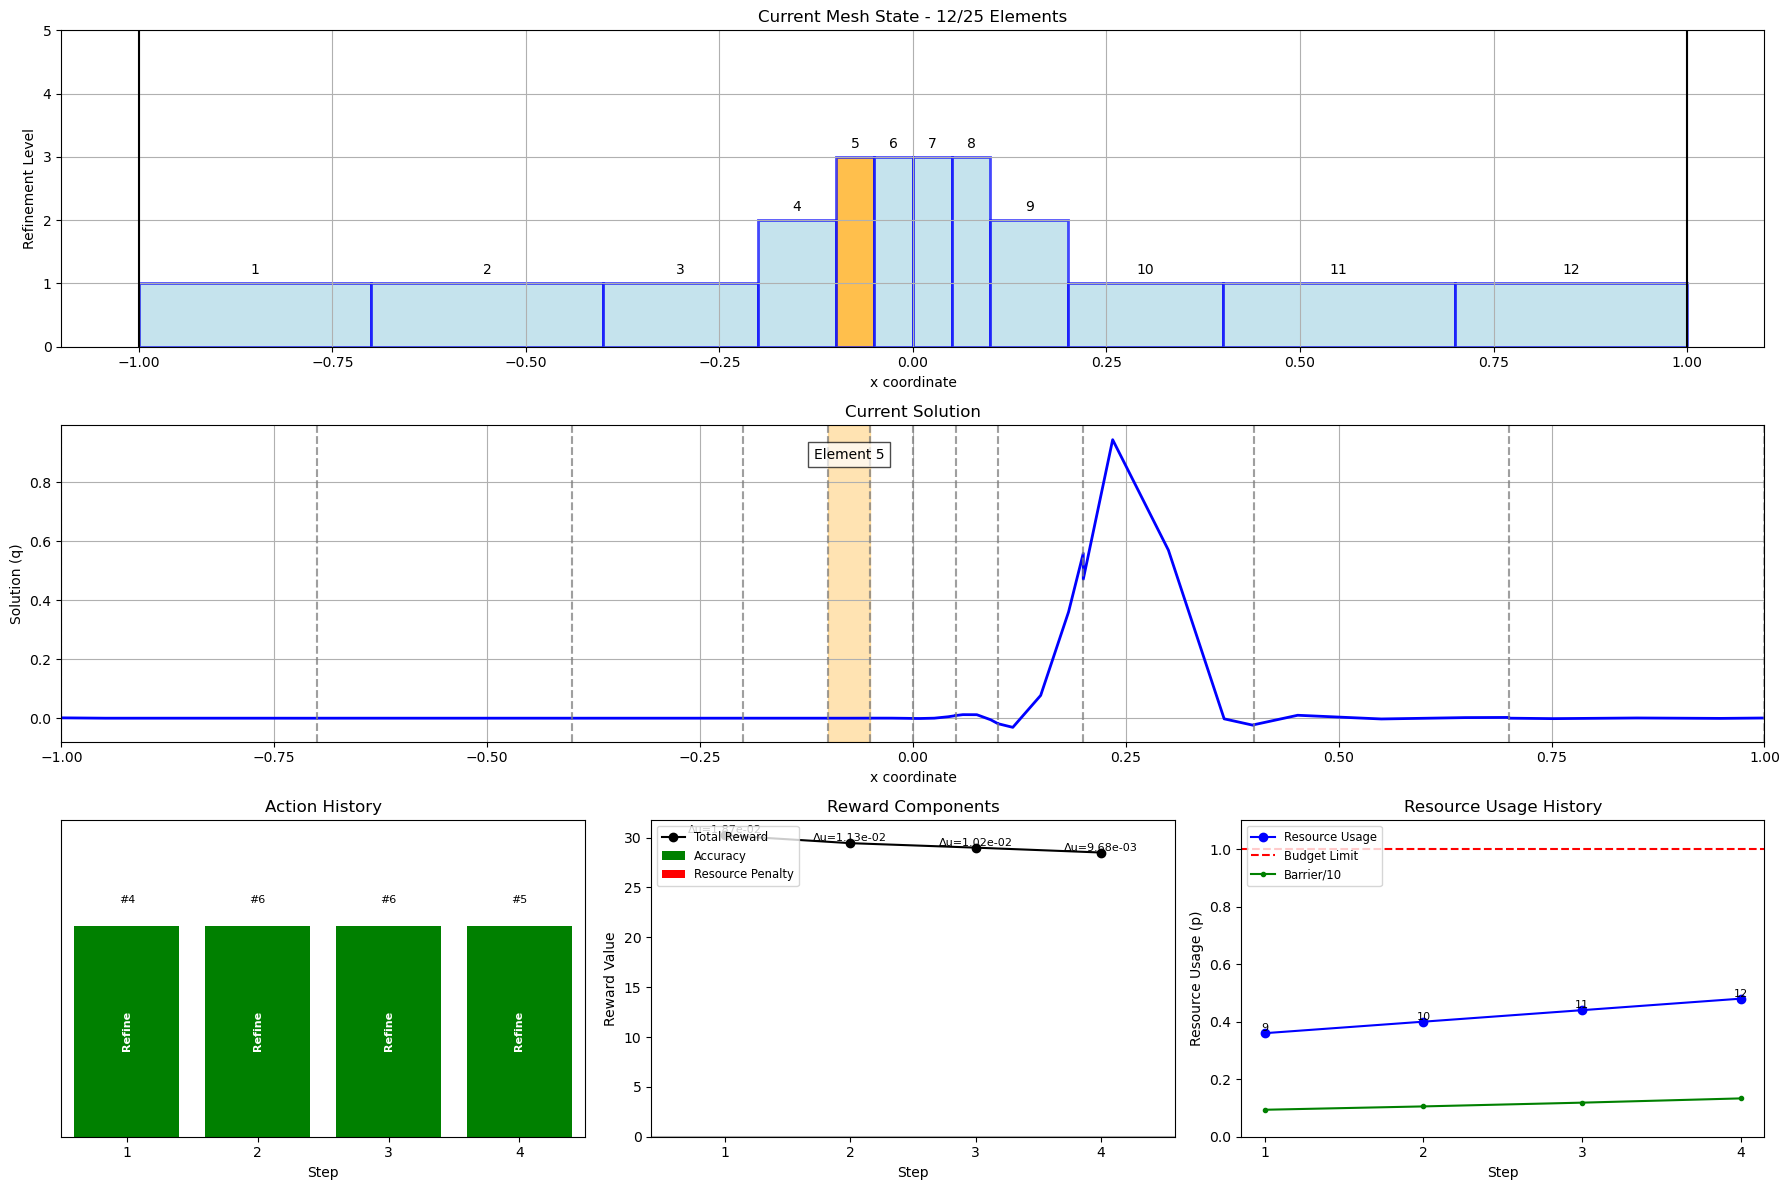

In [59]:
# Create and display the interactive tester
tester = InteractiveAMRTester(
    nop=4,
    initial_elements=np.array([-1, -0.5, 0, 0.5, 1]),
    max_level=4,
    element_budget=25,
    gamma_c=25.0,
    machine_eps=1e-16,
    initial_refinement_level=1,
    accuracy_scaling=1.0
)

tester.show_tester()